## Stellar lifeline Analysis

In [ ]:
!pip install lifelines
!pip install arviz

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 3.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=b61fa6b3b0c61d4e37c2c5be6ce533f15d7f7ec95c948f021529198dba49c8a5
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 3.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
     

In [6]:
!pip install pymc

  Using cached rich-14.0.0-py3-none-any.whl.metadata (18 kB)
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.5 MB/s eta 0:00:00a 0:00:01
Using cached rich-14.0.0-py3-none-any.whl (243 kB)
  Created wheel for cons: filename=cons-0.4.6-py3-none-any.whl size=9098 sha256=2d737303857df6467f8d602ba9b18d49413a5a673d371f33b287e569f254b343
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/91/0c/f7/7ba4ffbf0db6bf272bee59789131f6ec2d26966307a3054267
  Created wheel for logical-unification: filename=logical_unification-0.4.6-py3-none-any.whl size=13911 sha256=d26f8b786d50f8e519645a9c63a0424b33f76b08e657471443eb2a9388c39278
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/4b/07/cf/3fdaedafc40d7b1861c98be0df1bf3b2b3e87e03187fa95298
  Created whee

importing libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.linear_model import BayesianRidge
from scipy.optimize import curve_fit
import pymc as pm
import arviz as az

The distribution 
- supergiants at 25.7% 
- main sequence at 24.1%

is somewhat unexpected but analytically interesting

In [8]:
data= pd.read_csv('gaia_stars_final_classification.csv')

In [ ]:
main_sequence = data[data['final_phase'] == 'Main Sequence'].copy()

print(f"Found {len(main_sequence)} main sequence stars")

# Filter valid temperature range (solar-type stars)
main_sequence = main_sequence[(main_sequence['teff_gspphot'] > 3000) & 
                              (main_sequence['teff_gspphot'] < 10000)]
print(f"After temperature filtering: {len(main_sequence)} stars")

main_sequence.head()

Found 16955 main sequence stars
After temperature filtering: 16955 stars


,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,ruwe,teff_gspphot,phot_variable_flag,distance_pc,abs_mag,phase,cluster,gmm_cluster,dbscan_cluster,final_phase
0,251.589977,-50.638635,13.398257,0.017850,13.470652,14.585335,12.419784,2.165551,12.315269,0.951887,3730.1030,NOT_AVAILABLE,74.636572,9.105894,Main Sequence,0,0,0,Main Sequence
2,250.772902,-51.598985,10.326266,0.020964,13.695807,14.826818,12.635778,2.191039,7.051061,1.033412,3796.8080,NOT_AVAILABLE,96.840427,8.765524,Main Sequence,0,0,0,Main Sequence
5,285.774905,73.089686,13.956595,0.010605,12.161756,13.055846,11.230086,1.825760,-51.463833,1.110709,4160.7593,NOT_AVAILABLE,71.650717,7.885654,Main Sequence,0,0,0,Main Sequence
9,296.084675,70.476541,11.163278,0.013418,12.887754,13.816627,11.936210,1.880418,-9.795232,1.121394,4088.0550,NOT_AVAILABLE,89.579423,8.126713,Main Sequence,0,0,0,Main Sequence
11,285.636636,75.418511,23.857068,0.013330,12.086019,13.111851,11.080335,2.031516,-19.939575,1.135397,3422.9568,VARIABLE,41.916299,8.974104,Main Sequence,0,0,0,Main Sequence


In [15]:
main_sequence.isna().sum()

ra                    0
dec                   0
parallax              0
parallax_error        0
phot_g_mean_mag       0
phot_bp_mean_mag      0
phot_rp_mean_mag      0
bp_rp                 0
radial_velocity       0
ruwe                  0
teff_gspphot          0
phot_variable_flag    0
distance_pc           0
abs_mag               0
phase                 0
cluster               0
gmm_cluster           0
dbscan_cluster        0
final_phase           0
dtype: int64

### Stellar mass

In [19]:
# mass-temo relation: M ∝ T^{1/0.5} = T^2
solar_teff = 5772  # Solar effective temperature in Kelvin
main_sequence['mass_est'] = (main_sequence['teff_gspphot'] / solar_teff) ** 2

# Mass luminosity relation: L ∝ M^{3.5}
# Absolute magnitude to luminosity: M_abs = M_sun - 2.5 * log10(L / L_sun)
solar_abs_mag = 4.74  # Sun abs maginitude in G band
main_sequence['luminosity'] = 10 ** ((solar_abs_mag - main_sequence['abs_mag']) / 2.5)
main_sequence['mass_est_ml'] = main_sequence['luminosity'] ** (1 / 3.5)

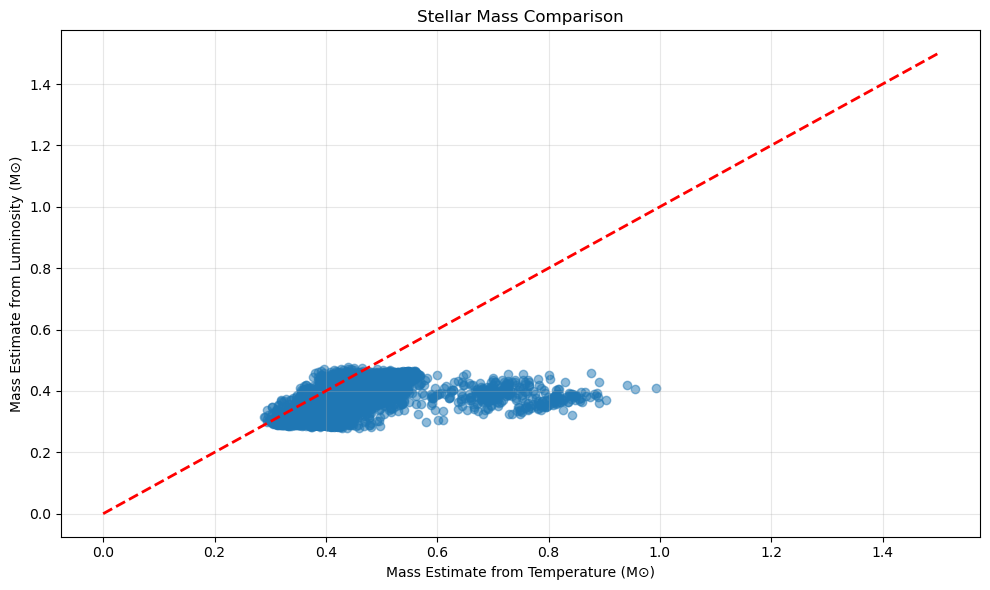

In [25]:
#Comparing estimates
plt.figure(figsize=(10, 6))
plt.scatter(main_sequence['mass_est'], main_sequence['mass_est_ml'], alpha=0.5)
plt.plot([0, 1.5], [0, 1.5], 'r--', lw=2)  # y=x line
plt.xlabel('Mass Estimate from Temperature (M⊙)')
plt.ylabel('Mass Estimate from Luminosity (M⊙)')
plt.title('Stellar Mass Comparison')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

main_sequence['mass'] = main_sequence['mass_est_ml']

### Theoretical Lifetime Model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


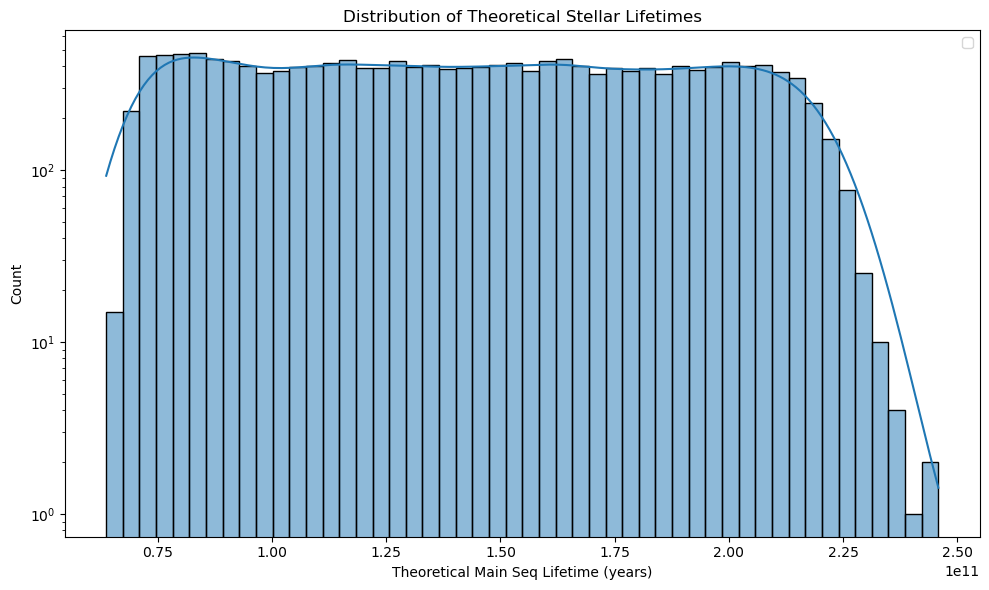

In [28]:
def theo_lifeline(mass):
    """
    Main seq lifeline formule: t = 10^10 * (M/M_sun)^-2.5 years
    """
    return 10**10 * (mass / 1.0)**-2.5

# Theoretical lifetime 
main_sequence['theo_lifetime'] = theo_lifeline(main_sequence['mass'])

plt.figure(figsize=(10, 6))
sns.histplot(main_sequence['theo_lifetime'], bins=50, kde=True)
plt.xlabel('Theoretical Main Seq Lifetime (years)')
plt.ylabel('Count')
plt.title('Distribution of Theoretical Stellar Lifetimes')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

---

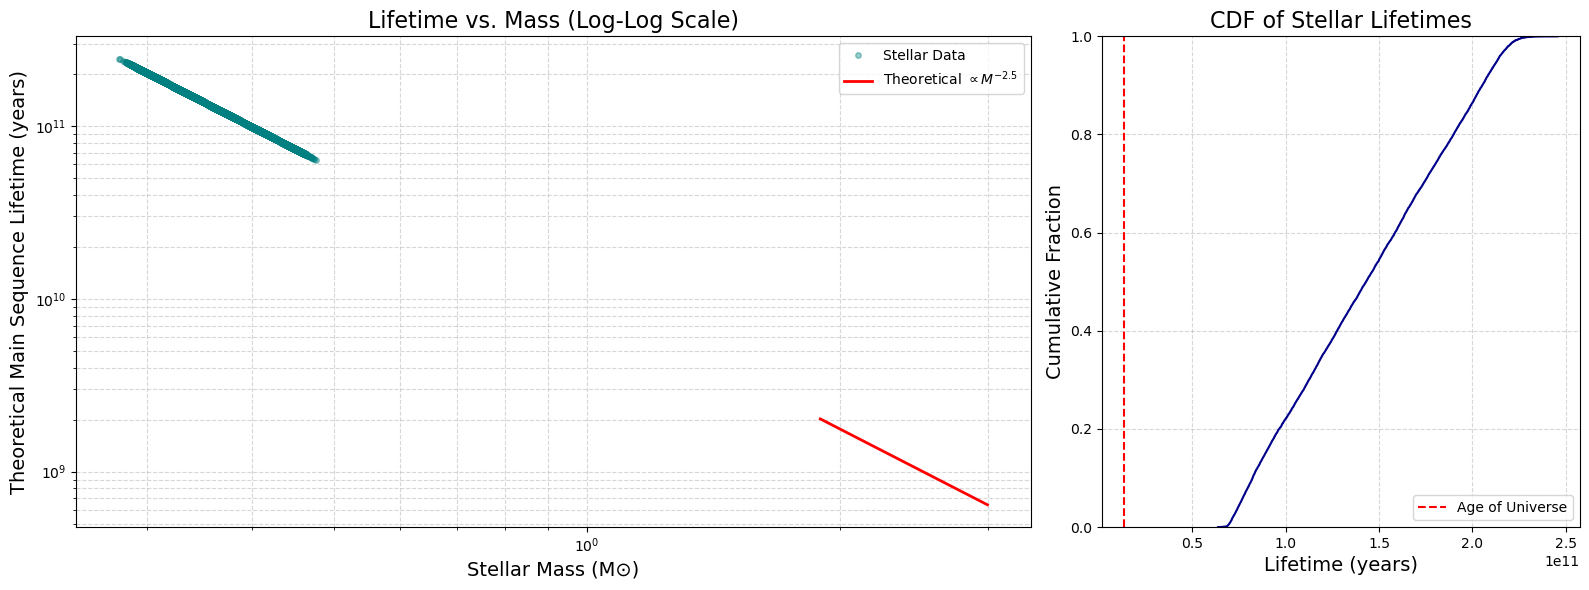

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# --------------------------
# Plot 1: Log-Log Lifetime vs. Mass
# --------------------------
ax = axes[0]
ax.loglog(main_sequence['mass'], main_sequence['theo_lifetime'], 'o', 
          alpha=0.4, markersize=4, color='teal', label='Stellar Data')
ax.set_xlabel('Stellar Mass (M⊙)', fontsize=14)
ax.set_ylabel('Theoretical Main Sequence Lifetime (years)', fontsize=14)
ax.set_title('Lifetime vs. Mass (Log-Log Scale)', fontsize=16)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Add theoretical line for reference
mass_range = np.logspace(
    np.min(main_sequence['mass']), 
    np.max(main_sequence['mass']), 
    100
)
ax.loglog(mass_range, theo_lifeline(mass_range), 'r-', lw=2, label='Theoretical $\\propto M^{-2.5}$')
ax.legend()

# --------------------------
# Plot 2: Cumulative Distribution (CDF)
# --------------------------
ax = axes[1]
sns.ecdfplot(main_sequence['theo_lifetime'], ax=ax, color='darkblue')
ax.axvline(13.6e9, color='red', linestyle='--', label='Age of Universe')
ax.set_xlabel('Lifetime (years)', fontsize=14)
ax.set_ylabel('Cumulative Fraction', fontsize=14)
ax.set_title('CDF of Stellar Lifetimes', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

---

### Sequence Analysis Setup

In [39]:
"""
Consider the `event` as the star leaving the main sequence
For the analysis, assume-
    1. All stars are "born" at the same time (simplification)
    2. Current time is the age of the universe (13.6 billion years)
"""

# Create "age" variable - simulated stellar ages
np.random.seed(42)  # For reproducibility
main_sequence['age'] = np.random.uniform(1e9, 13.6e9, len(main_sequence))

"""
Craeting event indicator-
    1 = Star has left the main sequence (if age > theoretical lifetime)
    0 = still on the main sequence (if age <= theoretical lifetime)
"""
main_sequence['event'] = (main_sequence['age'] > main_sequence['theo_lifetime']).astype(int)

# Duration is the minimum of age and theoretical lifetime
main_sequence['duration'] = np.minimum(main_sequence['age'], main_sequence['theo_lifetime'])
# Display the first few rows of the updated DataFrame
main_sequence.tail()
print(f"Fraction of stars that have left main sequence: {main_sequence['event'].mean():.2%}")

Fraction of stars that have left main sequence: 0.00%
